In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
wine = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/wine.csv')
print(wine.shape)
wine.head()

(6497, 4)


,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0
3,9.8,1.9,3.16,0.0
4,9.4,1.9,3.51,0.0


In [3]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   alcohol  6497 non-null   float64
 1   sugar    6497 non-null   float64
 2   pH       6497 non-null   float64
 3   class    6497 non-null   float64
dtypes: float64(4)
memory usage: 203.2 KB


In [4]:
wine.describe()

,alcohol,sugar,pH,class
count,6497.000000,6497.000000,6497.000000,6497.000000
mean,10.491801,5.443235,3.218501,0.753886
std,1.192712,4.757804,0.160787,0.430779
min,8.000000,0.600000,2.720000,0.000000
25%,9.500000,1.800000,3.110000,1.000000
50%,10.300000,3.000000,3.210000,1.000000
75%,11.300000,8.100000,3.320000,1.000000
max,14.900000,65.800000,4.010000,1.000000


array([[<Axes: title={'center': 'alcohol'}>,
        <Axes: title={'center': 'sugar'}>],
       [<Axes: title={'center': 'pH'}>,
        <Axes: title={'center': 'class'}>]], dtype=object)

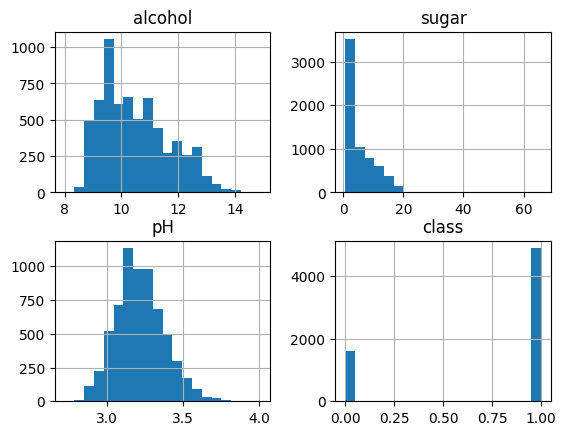

In [5]:
wine.hist(bins=20)

# 학습/검증 세트

In [10]:
wine.columns

Index(['alcohol', 'sugar', 'pH', 'class'], dtype='object')

In [14]:
data = wine.drop('class', axis=1).values
target = wine['class'].values
data.shape, target.shape

((6497, 3), (6497,))

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=.2, random_state=50)
X_train.shape, X_test.shape

((5197, 3), (1300, 3))

In [18]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(X_train)

,copy,True
,with_mean,True
,with_std,True


In [19]:
X_train_scaled = ss.transform(X_train)
X_test_scaled = ss.transform(X_test)

In [24]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [25]:
pred = clf.predict(X_test)
print(clf.score(X_train_scaled, y_train))
print(clf.score(X_test_scaled, y_test))

0.7796805849528574
0.7853846153846153


In [28]:
clf.coef_, clf.intercept_ # 학습 계수(기울기) 및 절편(편향)

(array([[ 0.52119637,  1.6623573 , -0.69600674]]), array([1.76817573]))

점수가 낮음. 근데 왜 이런 점수를 보이는지 설명하기 어려움. 대부분의 머신러닝은 학습 결과를 설명하기 어려운 특징을 가짐

# 결정 트리

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt_clf = DecisionTreeClassifier()
dt_clf.fit(X_train_scaled, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [32]:
print(dt_clf.score(X_train_scaled, y_train))
print(dt_clf.score(X_test_scaled, y_test))

0.9974985568597268
0.8653846153846154


로지스틱 회귀보다 훨씬 점수가 높은 것을 확인할 수 있다

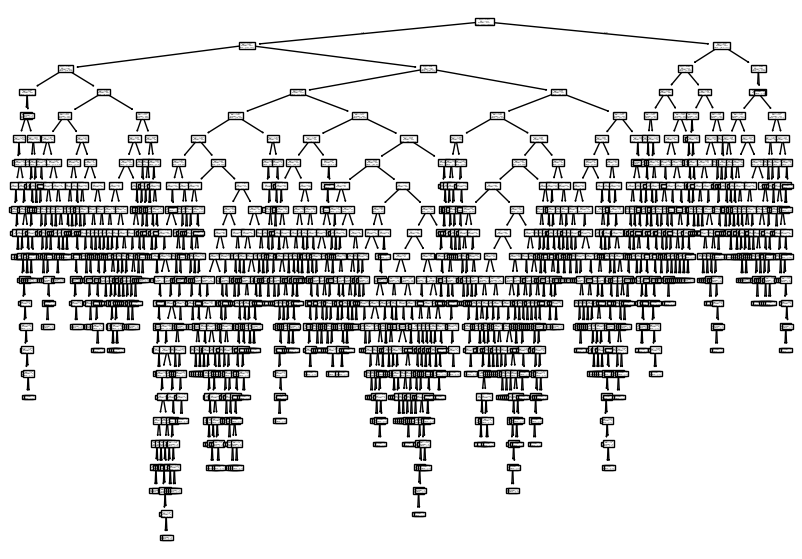

In [33]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(10,7))
plot_tree(dt_clf)
plt.show()

시각화 또한 결과 이해에 도움이 될 수 있다(명확한 기준으로 분류를 하기 때문임)

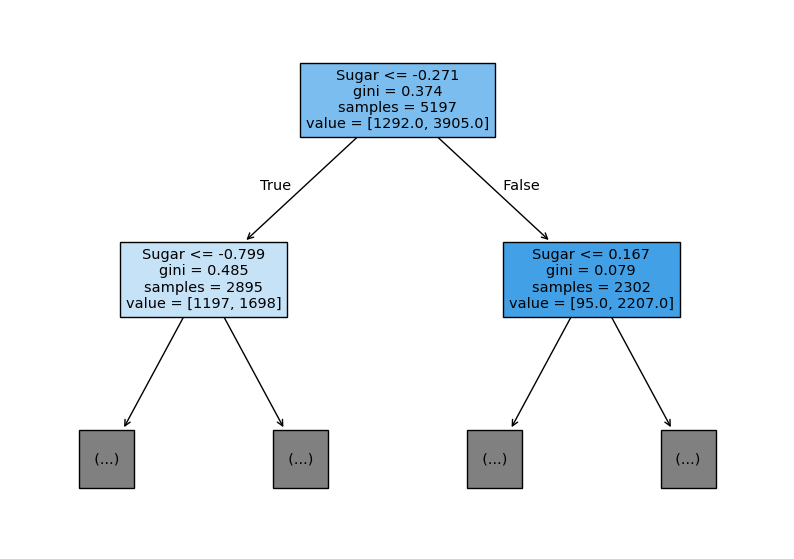

In [34]:
plt.figure(figsize=(10,7))
plot_tree(dt_clf, max_depth=1, filled=True, feature_names=['Alcohol', 'Sugar', 'pH'])
plt.show()

### 가지치기

In [49]:
clf2 = DecisionTreeClassifier(max_depth=7, random_state=50)
clf2.fit(X_train_scaled, y_train)
print(clf2.score(X_train_scaled, y_train))
print(clf2.score(X_test_scaled, y_test))

0.8851260342505292
0.8707692307692307


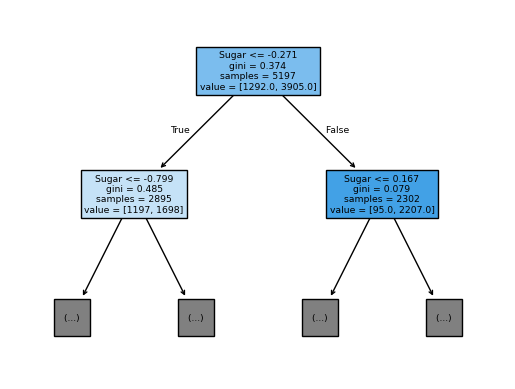

In [52]:
plot_tree(clf2, max_depth=1, filled=True, feature_names=['Alcohol', 'Sugar', 'pH'])
plt.show()

### 전처리 필요없는 결정트리

In [ ]:
clf3 = DecisionTreeClassifier()
clf3.fit(X_train, y_train) # 일반적으로 보는 시각에서는 전처리를 안하고 바로 데이터를 넣는 방식을 선호하며 하는 추세임
print(clf3.score(X_train, y_train), clf3.score(X_test, y_test))

0.9974985568597268 0.8646153846153846


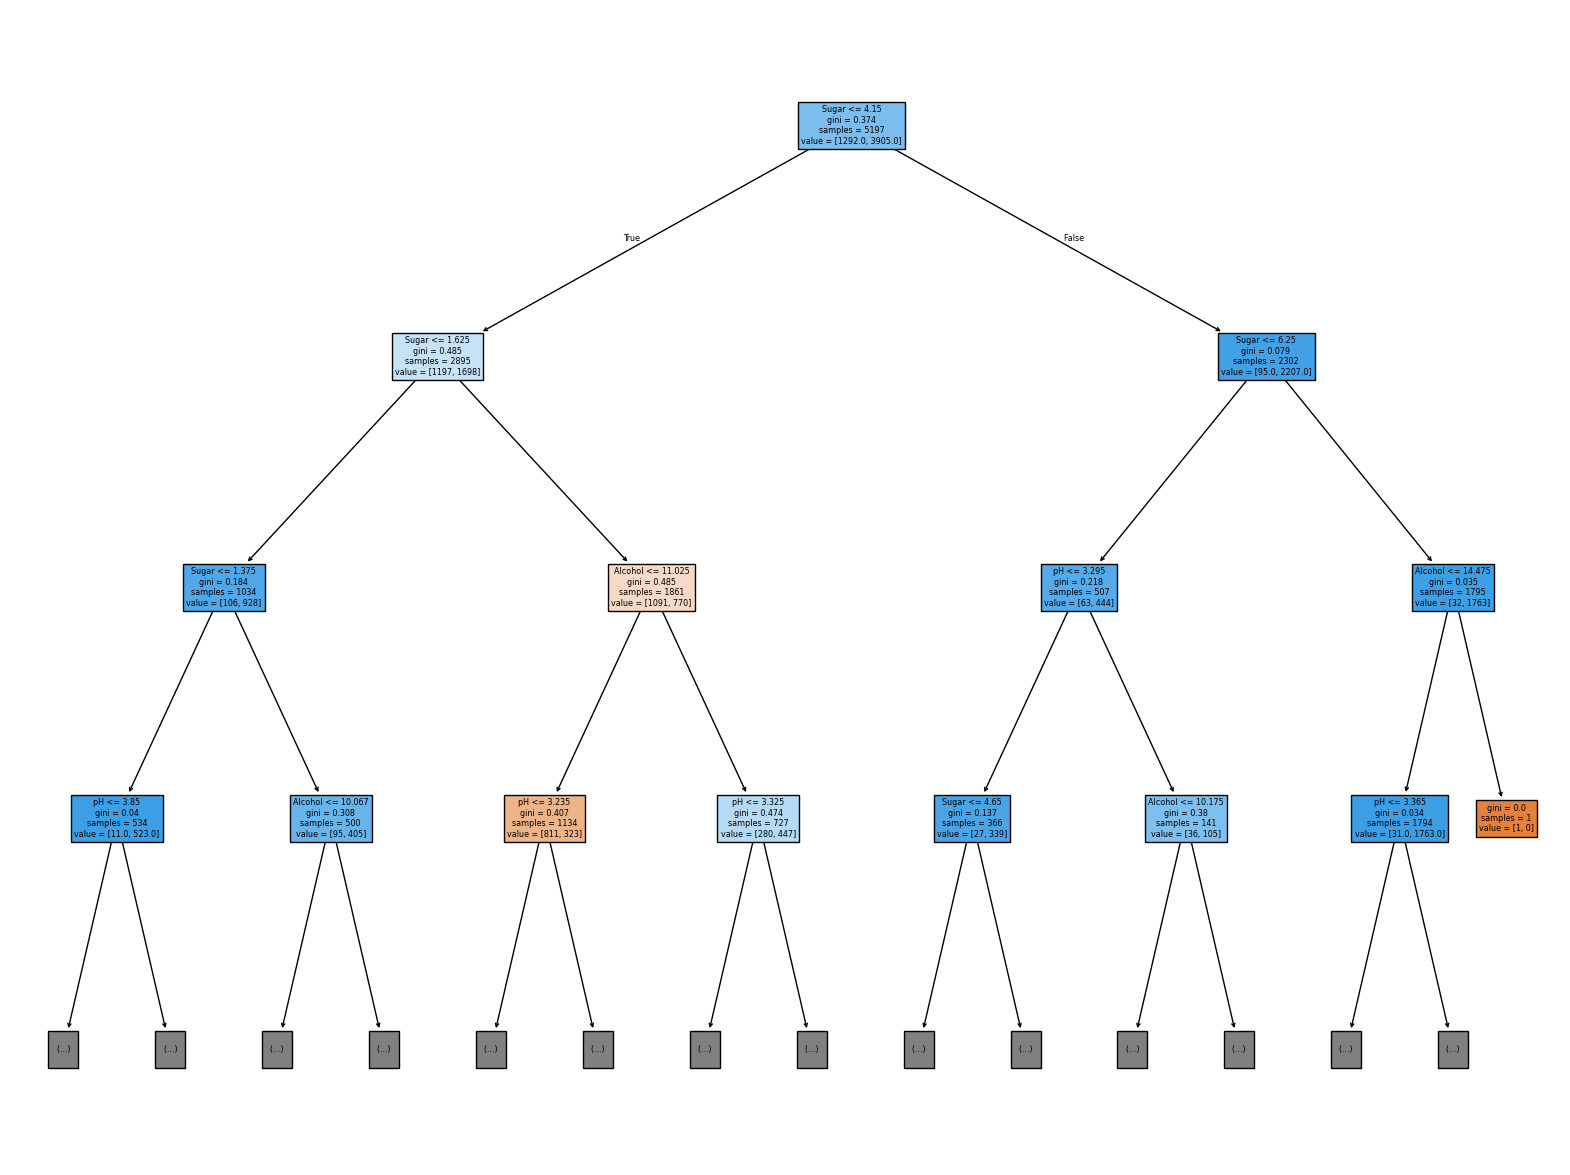

In [59]:
plt.figure(figsize=(20,15))
plot_tree(clf3, max_depth=3, filled=True, feature_names=['Alcohol', 'Sugar', 'pH'])
plt.show()

### 특성 중요도 확인

In [ ]:
clf3.feature_importances_ # ['Alcohol', 'Sugar', 'pH'] 중 sugar가 중요도가 높다는 것을 알려줌

array([0.24111462, 0.50423868, 0.2546467 ])

# 불순물 기준 변경

In [ ]:
clf4 = DecisionTreeClassifier(min_impurity_decrease=0.0005, random_state=50) # 불순물 추가
clf4.fit(X_train, y_train)
print(clf4.score(X_train, y_train))
print(clf4.score(X_test, y_test))

0.8851260342505292
0.8592307692307692


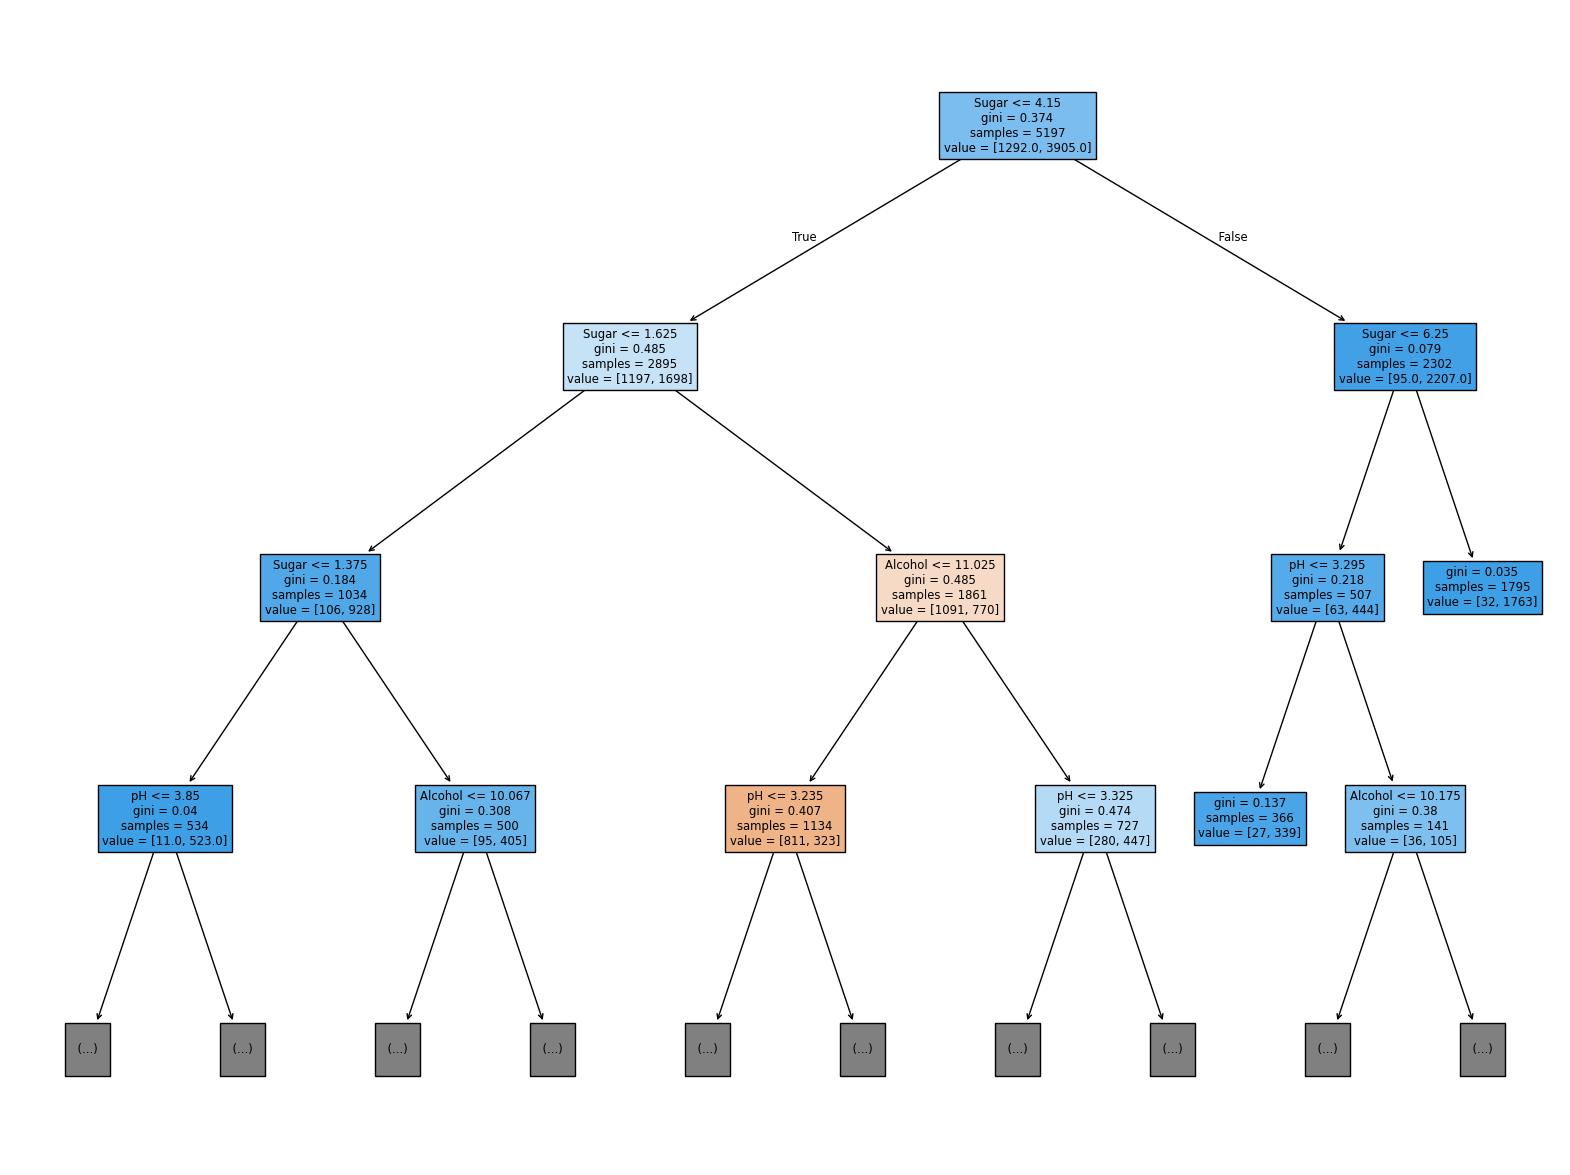

In [60]:
plt.figure(figsize=(20,15))
plot_tree(clf4, max_depth=3, filled=True, feature_names=['Alcohol', 'Sugar', 'pH'])
plt.show()

In [62]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# PREVIOUS_MAX_ROWS = pd.options.display.max_rows
# pd.options.display.max_rows = 20
# np.set_printoptions(precision=4, suppress=True)

### 인코딩

In [ ]:
from sklearn.preprocessing import LabelEncoder

items = ['TV', '냉장고','전자레인지', '세탁기', '선풍기', '에어프라이기']
encoder = LabelEncoder()
encoder.fit(items) # 배열만 들어가면 됨

LabelEncoder()

In [65]:
labels = encoder.transform(items)
print(labels)

[0 1 5 3 2 4]


In [ ]:
#인코딩 클래스
encoder.classes_

array(['TV', '냉장고', '선풍기', '세탁기', '에어프라이기', '전자레인지'], dtype='<U6')

### 디코딩

In [113]:
# 디코딩
encoder.inverse_transform(labels)

c:\Users\USER\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:151: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0, 1, 2, 3, 4, 5, 3])

### fit_transfrom()

In [75]:
LabelEncoder.fit_transform(items, labels)

c:\Users\USER\miniconda3\Lib\site-packages\sklearn\preprocessing\_label.py:111: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  self.classes_, y = _unique(y, return_inverse=True)


array([0, 1, 5, 3, 2, 4])

In [123]:
items

['TV', '냉장고', '선풍기', '세탁기', '에어프라이기', '전자레인지', '세탁기']

In [124]:
labels

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5],
       [3]])

# 여기 놓침;;

In [ ]:
origin

In [ ]:
items.TV = (origin == 'TV' * 1.0)
items.냉장고 = (origin == '냉장고' * 1.0)
items.에어컨 = (origin == '에어컨' * 1.0)
items.전자레인지 = (origin == '전자레인지' * 1.0)
items

In [ ]:
# Integer encoding


# 아래는 정상 코드

### 원-핫 인코딩 구현

In [72]:
items = pd.DataFrame({'종류': ['TV', '냉장고', '선풍기', '세탁기', '에어프라이기', '전자레인지']})
items

,종류
0,TV
1,냉장고
2,선풍기
3,세탁기
4,에어프라이기
5,전자레인지


In [73]:
ohe = pd.get_dummies(items)
ohe

,종류_TV,종류_냉장고,종류_선풍기,종류_세탁기,종류_에어프라이기,종류_전자레인지
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,True,False,False,False
3,False,False,False,True,False,False
4,False,False,False,False,True,False
5,False,False,False,False,False,True


### 사이킷런 OneHotEncoder

In [78]:
from sklearn.preprocessing import OneHotEncoder
items = ['TV', '냉장고', '선풍기', '세탁기', '에어프라이기', '전자레인지', '세탁기']
encoder = LabelEncoder()
labels = encoder.fit_transform(items)
labels

array([0, 1, 2, 3, 4, 5, 3])

In [79]:
labels.reshape(-1,1)

array([[0],
       [1],
       [2],
       [3],
       [4],
       [5],
       [3]])

In [80]:
labels = labels.reshape(-1,1) # 2차원으로 변환

In [81]:
# 원-핫 인코딩을 적용합니다. 
oh_encoder = OneHotEncoder()
oh_encoder.fit(labels)

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [85]:
oh_labels = oh_encoder.transform(labels)
type(oh_labels) # 희소행렬로 리턴

scipy.sparse._csr.csr_matrix

In [86]:
oh_labels

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 7 stored elements and shape (7, 6)>

In [89]:
oh_labels.toarray(), oh_labels.shape # 원핫인코딩 데이터 및 차원

(array([[1., 0., 0., 0., 0., 0.],
        [0., 1., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0.],
        [0., 0., 0., 0., 1., 0.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0., 0.]]),
 (7, 6))

In [103]:
from sklearn.datasets import load_iris
iris = load_iris()
iris_df = pd.DataFrame(iris.data, columns=iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [108]:
iris_df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [109]:
iris_df.var() #분산

sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64

In [ ]:
df = iris_df.copy()
for c in df.columns:
    if iris_df[c].std != 0:
        df[c] = (iris_df[c] - iris_df[c].mean() / iris_df[c].std()) # 표준화
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-1.956602,-3.514384,-0.728819,-1.373438
1,-2.156602,-4.014384,-0.728819,-1.373438
2,-2.356602,-3.814384,-0.828819,-1.373438
3,-2.456602,-3.914384,-0.628819,-1.373438
4,-2.056602,-3.414384,-0.728819,-1.373438
...,...,...,...,...
145,-0.356602,-4.014384,3.071181,0.726562
146,-0.756602,-4.514384,2.871181,0.326562
147,-0.556602,-4.014384,3.071181,0.426562
148,-0.856602,-3.614384,3.271181,0.726562


In [116]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)
df = pd.DataFrame(iris_scaled, columns=iris.feature_names)
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444
...,...,...,...,...
145,1.038005,-0.131979,0.819596,1.448832
146,0.553333,-1.282963,0.705921,0.922303
147,0.795669,-0.131979,0.819596,1.053935
148,0.432165,0.788808,0.933271,1.448832


In [117]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,1.500000e+02,1.500000e+02,1.500000e+02,1.500000e+02
mean,-1.468455e-15,-1.823726e-15,-1.610564e-15,-9.473903e-16
std,1.003350e+00,1.003350e+00,1.003350e+00,1.003350e+00
min,-1.870024e+00,-2.433947e+00,-1.567576e+00,-1.447076e+00
25%,-9.006812e-01,-5.923730e-01,-1.226552e+00,-1.183812e+00
50%,-5.250608e-02,-1.319795e-01,3.364776e-01,1.325097e-01
75%,6.745011e-01,5.586108e-01,7.627583e-01,7.906707e-01
max,2.492019e+00,3.090775e+00,1.785832e+00,1.712096e+00


In [118]:
df.var()

sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64

In [119]:
df.std()

sepal length (cm)    1.00335
sepal width (cm)     1.00335
petal length (cm)    1.00335
petal width (cm)     1.00335
dtype: float64

### MinMaxScaler

In [122]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
iris_scaled = scaler.fit_transform(iris_df)
df2 = pd.DataFrame(iris_scaled, columns=iris_df.columns)
df2.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,0.428704,0.440556,0.467458,0.458056
std,0.230018,0.181611,0.299203,0.317599
min,0.000000,0.000000,0.000000,0.000000
25%,0.222222,0.333333,0.101695,0.083333
50%,0.416667,0.416667,0.567797,0.500000
75%,0.583333,0.541667,0.694915,0.708333
max,1.000000,1.000000,1.000000,1.000000


# 교차 검증과 그리드 서치

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [141]:
wine = pd.read_csv('https://raw.githubusercontent.com/rickiepark/hg-mldl/master/wine.csv')
wine.head(3)

,alcohol,sugar,pH,class
0,9.4,1.9,3.51,0.0
1,9.8,2.6,3.20,0.0
2,9.8,2.3,3.26,0.0


In [142]:
X = wine.drop('class', axis=1).values
y = wine['class']

In [143]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=50)
print(X_train.shape, X_test.shape)

(5197, 3) (1300, 3)


In [144]:
sub_train, val_train, sub_target, val_target = train_test_split(X_train, y_train, test_size=.2, random_state=50)
sub_train.shape, val_train.shape

((4157, 3), (1040, 3))

In [147]:
sub_train.shape, sub_target.shape

((4157, 3), (4157,))

In [152]:
dt_clf = DecisionTreeClassifier(random_state=50)
dt_clf.fit(sub_train, sub_target)
print(dt_clf.score(sub_train, sub_target))
print(dt_clf.score(val_train, val_target))

0.9980755352417608
0.8596153846153847


In [ ]:
from sklearn.metrics import classification_report
pred1 = dt_clf.predict(sub_train)
pred2 = dt_clf.predict(val_train)
print(classification_report(sub_target, pred))
print(classification_report(val_target, pred))

### 교차 검증

In [134]:
from sklearn.model_selection import cross_validate
scores = cross_validate(dt_clf, X_train, y_train)
scores

{'fit_time': array([0.00692344, 0.00663996, 0.00805259, 0.00640845, 0.00649452]),
 'score_time': array([0.001297  , 0.00230622, 0.00203204, 0.00109673, 0.00125051]),
 'test_score': array([0.85480769, 0.85384615, 0.86525505, 0.85563041, 0.8719923 ])}

In [149]:
np.mean(scores['test_score'])

np.float64(0.860306322647516)

In [ ]:
from sklearn.model_selection import StratifiedKFold
# K폴드 교차검증
stfold = StratifiedKFold() # n_split의 수가 기본 5로 설정되어 있음. 이걸 변경하면 검증 횟수를 변경가능
# scores = cross_validate(dt_clf, X_train, y_train, cv=stfold)
scores = cross_validate(dt_clf, X, y, cv=stfold)
print(np.mean(scores['test_score']))

0.8099133060934445


In [153]:
stfold = StratifiedKFold(n_splits=10, shuffle=True, random_state=50)
scores = cross_validate(dt_clf, X_train, y_train, cv=stfold)
print(np.mean(scores['test_score']))

0.8645342374388617


# 하이퍼 파라미터 튜닝
### GridSearchCV

In [158]:
from sklearn.model_selection import GridSearchCV

params = {'min_impurity_decrease': [i/10000 for i in range(1, 6)]}

dt_clf = DecisionTreeClassifier(random_state=50)
gs = GridSearchCV(dt_clf, param_grid=params, n_jobs=-1)
gs.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=50)
,param_grid,"{'min_impurity_decrease': [0.0001, 0.0002, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [159]:
dt = gs.best_estimator_ # <-- DecisionTreeClass
print(dt.score(X_train, y_train))

0.9299595920723495


In [ ]:
gs.best_params_ # 가장 결과가 좋은 값

{'min_impurity_decrease': 0.0002}

In [162]:
gs.cv_results_.keys()

dict_keys(['mean_fit_time', 'std_fit_time', 'mean_score_time', 'std_score_time', 'param_min_impurity_decrease', 'params', 'split0_test_score', 'split1_test_score', 'split2_test_score', 'split3_test_score', 'split4_test_score', 'mean_test_score', 'std_test_score', 'rank_test_score'])

In [164]:
gs.cv_results_['params']

[{'min_impurity_decrease': 0.0001},
 {'min_impurity_decrease': 0.0002},
 {'min_impurity_decrease': 0.0003},
 {'min_impurity_decrease': 0.0004},
 {'min_impurity_decrease': 0.0005}]

In [165]:
gs.cv_results_['mean_test_score']

array([0.86934923, 0.86973273, 0.8683875 , 0.86511513, 0.86588325])

In [170]:
params = {
    'min_impurity_decrease': np.arange(0.0001, 0.001, 0.0001),
    'max_depth': range(5,20),
    'min_samples_split': range(2,100,10)
}

In [171]:
dt_clf = DecisionTreeClassifier(random_state=50)
gs = GridSearchCV(dt_clf, param_grid=params, n_jobs=-1)
gs.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=50)
,param_grid,"{'max_depth': range(5, 20), 'min_impurity_decrease': array([0.0001... 0.0009]), 'min_samples_split': range(2, 100, 10)}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [173]:
gs.best_params_

{'max_depth': 15,
 'min_impurity_decrease': np.float64(0.0001),
 'min_samples_split': 2}

In [172]:
np.max(gs.cv_results_['mean_test_score'])

np.float64(0.8712730436070186)

In [174]:
dt_clf2 = DecisionTreeClassifier(
    max_depth=15,
    min_impurity_decrease=0.0001,
    min_samples_split=2,
    random_state=50
)

### 랜덤 서치

In [175]:
from scipy.stats import uniform, randint
rgen = randint(0, 10)
rgen.rvs(10)

array([5, 4, 8, 9, 5, 6, 0, 8, 1, 1])

In [176]:
np.unique(rgen.rvs(1000), return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9]),
 array([ 99,  86, 111,  93, 115, 101,  85, 115,  98,  97]))

In [177]:
ugen = uniform(0,1)
ugen.rvs(10)

array([0.89087809, 0.02968357, 0.44072617, 0.86844566, 0.31000152,
       0.59069222, 0.08669535, 0.06262904, 0.34275708, 0.94786299])

In [178]:
params = {
    'min_impurity_decrease': uniform(0.0001, 0.001),
    'max_depth': range(20,50),
    'min_samples_split': randint(2,25),
    'min_samples_leaf': randint(1,25)
}

### RandomizedSearchCV

In [188]:
from sklearn.model_selection import RandomizedSearchCV

dt_clf = DecisionTreeClassifier(random_state=50)
gs = RandomizedSearchCV(dt_clf, params, n_iter=100, n_jobs=-1, random_state=50)
gs.fit(X_train, y_train)

,estimator,DecisionTreeC...ndom_state=50)
,param_distributions,"{'max_depth': range(20, 50), 'min_impurity_decrease': <scipy.stats....001C0CE2E91D0>, 'min_samples_leaf': <scipy.stats....001C0CE2EB4D0>, 'min_samples_split': <scipy.stats....001C0CE2EB750>}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,50
,error_score,nan


In [189]:
gs.best_params_

{'max_depth': 36,
 'min_impurity_decrease': np.float64(0.00015640163917149342),
 'min_samples_leaf': 1,
 'min_samples_split': 2}

In [190]:
np.max(gs.cv_results_['mean_test_score'])

np.float64(0.8724267046716518)

In [191]:
dt = gs.best_estimator_
dt.score(X_test, y_test)

0.8692307692307693

### splitter 매개변수

In [196]:
from sklearn.model_selection import StratifiedKFold

splitter = StratifiedKFold(n_splits=10, shuffle=True, random_state=50)
dt_cls = DecisionTreeClassifier(splitter='random', random_state=50)
gs = RandomizedSearchCV(dt_cls, params, cv=splitter, n_iter=100, n_jobs=-1, random_state=50)
gs.fit(X_train, y_train)

,estimator,DecisionTreeC...tter='random')
,param_distributions,"{'max_depth': range(20, 50), 'min_impurity_decrease': <scipy.stats....001C0CE2E91D0>, 'min_samples_leaf': <scipy.stats....001C0CE2EB4D0>, 'min_samples_split': <scipy.stats....001C0CE2EB750>}"
,n_iter,100
,scoring,None
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,50
,error_score,nan


In [197]:
gs.best_params_

{'max_depth': 24,
 'min_impurity_decrease': np.float64(0.00012143623215939916),
 'min_samples_leaf': 7,
 'min_samples_split': 24}

In [198]:
np.max(gs.cv_results_['mean_test_score'])

np.float64(0.7723558618645325)

In [199]:
dt = gs.best_estimator_
dt.score(X_test, y_test)

0.7653846153846153